# WEEK 3 of the Capstone Project

### STEP 0 - IMPORT RELEVANT PACKAGES

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import importlib
import scripts.utils.data_utils as data_utils
importlib.reload(data_utils)

# Import utility functions
from scripts.utils.data_utils import (
    load_initial_data,
    load_week1_data,
    load_week2_data,
    combine_data,
    plot_2d_scatter_with_distribution,
    plot_3d_scatter_with_distribution,
    plot_tsne_with_distribution,
    plot_bo_visualization_2d,
    plot_function_summary_subplot
)


### STEP 1 - DOWNLOAD THE INITIAL DATA

In [2]:
# Load initial data using utility function
base_dir = Path('/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/data/initial_data')
initial_data = load_initial_data(base_dir)

print(f"Loaded initial data for {len(initial_data)} functions")
for function_name, data in initial_data.items():
    print(f"  {function_name}: {data['inputs'].shape[0]} samples, {data['inputs'].shape[1]} dimensions")


Loaded initial data for 8 functions
  function_1: 10 samples, 2 dimensions
  function_2: 10 samples, 2 dimensions
  function_3: 15 samples, 3 dimensions
  function_4: 30 samples, 4 dimensions
  function_5: 20 samples, 4 dimensions
  function_6: 20 samples, 5 dimensions
  function_7: 30 samples, 6 dimensions
  function_8: 40 samples, 8 dimensions


### STEP 2 - DOWNLOAD THE WEEK 1 DATA

In [3]:
# Load week1 data using utility function
week1_dir = Path('/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/data/week1')
week1_data = load_week1_data(week1_dir)

print(f"Loaded week1 data for {len(week1_data)} functions")
for function_name, data in week1_data.items():
    print(f"  {function_name}: Input shape = {data['input'].shape}, Output = {data['output']}")


Loaded week1 data for 8 functions
  function_1: Input shape = (2,), Output = 2.6752879910742468e-09
  function_2: Input shape = (2,), Output = 0.42721035515778233
  function_3: Input shape = (3,), Output = -0.45300818056360315
  function_4: Input shape = (4,), Output = -25.81769735182645
  function_5: Input shape = (4,), Output = 4219.157963029058
  function_6: Input shape = (5,), Output = -2.6736180536592746
  function_7: Input shape = (6,), Output = 0.013680510023283559
  function_8: Input shape = (8,), Output = 6.0739207860211


### STEP 3 - DOWNLOAD THE WEEK 2 DATA

In [4]:
# Load week2 data using utility function (files store the latest line as the newest week)
week2_dir = Path('/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/data/week2')
week2_data = load_week2_data(week2_dir)

print(f"Loaded week2 data for {len(week2_data)} functions")
for function_name, data in week2_data.items():
    print(f"  {function_name}: Input shape = {data['input'].shape}, Output = {data['output']}")


Loaded week2 data for 8 functions
  function_1: Input shape = (2,), Output = 2.308810742126141e-248
  function_2: Input shape = (2,), Output = 0.09143573616583116
  function_3: Input shape = (3,), Output = -0.16648410423830667
  function_4: Input shape = (4,), Output = 0.07635232865804342
  function_5: Input shape = (4,), Output = 4139.609565498906
  function_6: Input shape = (5,), Output = -1.732308297257106
  function_7: Input shape = (6,), Output = 1.9964705720993239
  function_8: Input shape = (8,), Output = 9.8362097005135


### FUNCTION 1 - COMBINED DATA AND VISUALISATION

In [5]:
# Function 1 - Combine original data with week 1 and week 2 data
function_name = 'function_1'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']

# Get week 2 new input and output
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Combine inputs: original + week 1 + week 2
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1)
])

# Combine outputs: original + week 1 + week 2
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output])
])

print("=" * 60)
print(f"FUNCTION 1 - COMBINED DATA (Week 1 + Week 2)")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nWeek 1 input: {week1_input}")
print(f"Week 2 input: {week2_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nWeek 1 output: {week1_output}")
print(f"Week 2 output: {week2_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 1 - COMBINED DATA (Week 1 + Week 2)

Original inputs shape: (10, 2)
Original inputs:
[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]]

Week 1 input: [0.5 0.5]
Week 2 input: [0. 0.]

Combined inputs shape: (12, 2)
Combined inputs:
[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.5        0.5       ]
 [0.         0.        ]]

------------------------------------------------------------

Original outputs shape: (10,)
Original outputs:
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677

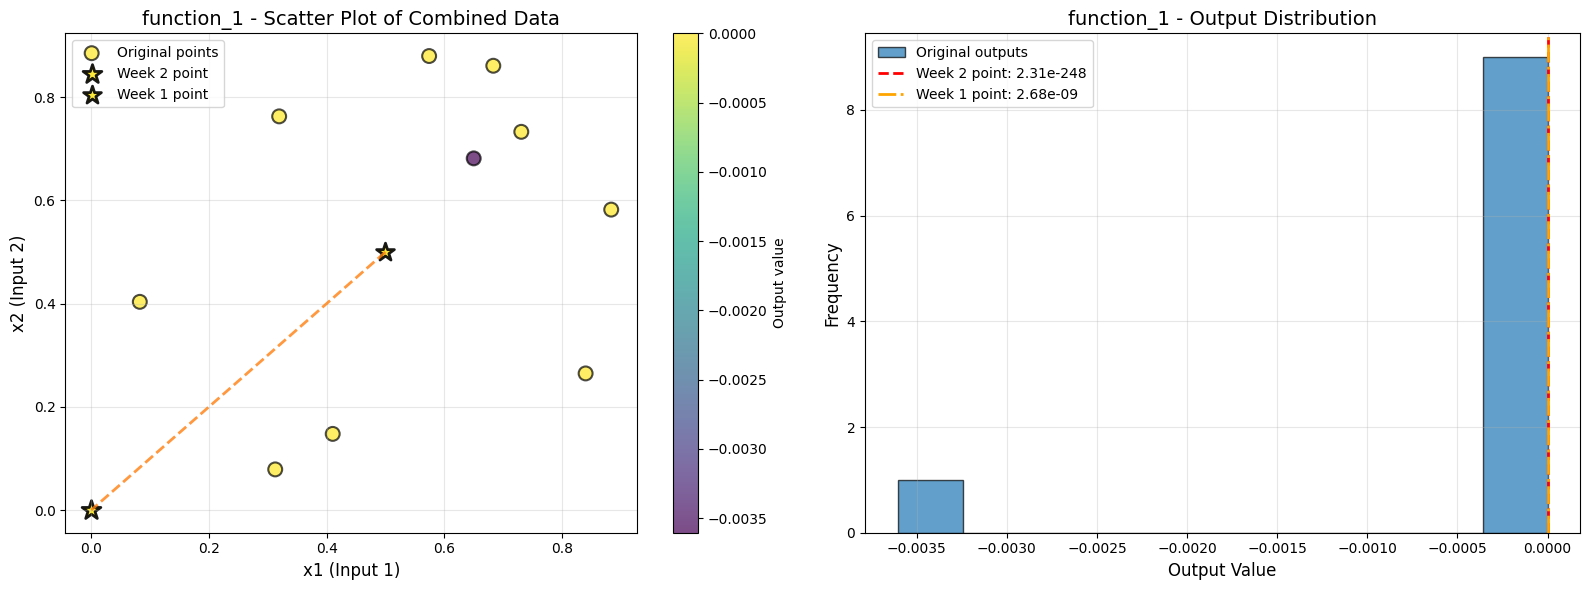


Combined inputs shape: (12, 2)
Combined outputs shape: (12,)


In [6]:
# Function 1 - Visualization using utility function
function_name = 'function_1'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Visualize: show both Week 1 and Week 2 points with a connecting line
plot_2d_scatter_with_distribution(
    original_inputs, original_outputs, 
    week2_input, week2_output, 
    function_name,
    prior_input=week1_input,
    prior_output=week1_output,
    prior_point_label="Week 1 point",
    new_point_label="Week 2 point",
    connect_points=True,
    connect_color="tab:orange"
)

# Print combined data info
combined_inputs = np.vstack([original_inputs, week1_input.reshape(1, -1), week2_input.reshape(1, -1)])
combined_outputs = np.concatenate([original_outputs, np.array([week1_output]), np.array([week2_output])])
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 2 - COMBINED DATA AND VISUALISATION

In [7]:
# Function 2 - Combine original data with week 1 and week 2 data
function_name = 'function_2'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']

# Get week 2 new input and output
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Combine inputs: original + week 1 + week 2
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1)
])

# Combine outputs: original + week 1 + week 2
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output])
])

print("=" * 60)
print(f"FUNCTION 2 - COMBINED DATA (Week 1 + Week 2)")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nWeek 1 input: {week1_input}")
print(f"Week 2 input: {week2_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nWeek 1 output: {week1_output}")
print(f"Week 2 output: {week2_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 2 - COMBINED DATA (Week 1 + Week 2)

Original inputs shape: (10, 2)
Original inputs:
[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]]

Week 1 input: [0.65 0.5 ]
Week 2 input: [0.839041 1.      ]

Combined inputs shape: (12, 2)
Combined inputs:
[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.65       0.5       ]
 [0.839041   1.        ]]

------------------------------------------------------------

Original outputs shape: (10,)
Original outputs:
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522]

Week 1 ou

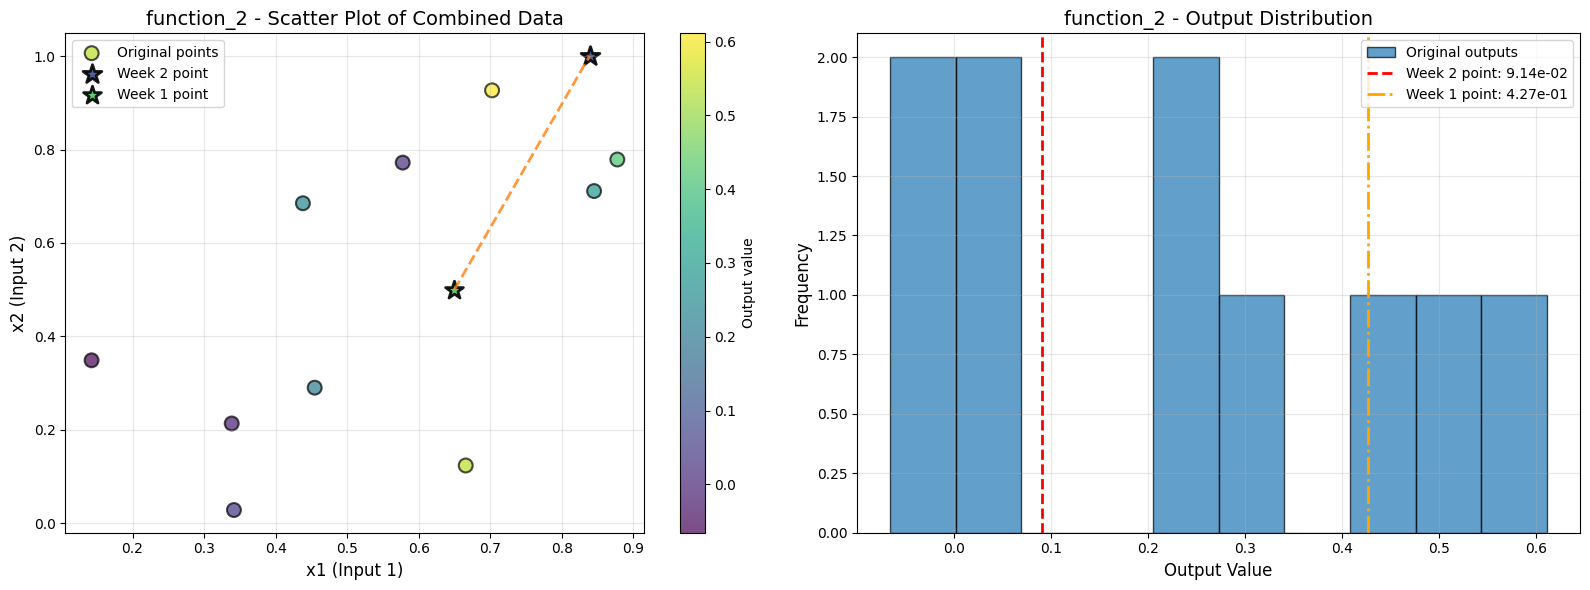


Combined inputs shape: (12, 2)
Combined outputs shape: (12,)


In [8]:
# Function 2 - Visualization using utility function
function_name = 'function_2'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Visualize: show both Week 1 and Week 2 points with a connecting line
plot_2d_scatter_with_distribution(
    original_inputs, original_outputs, 
    week2_input, week2_output, 
    function_name,
    prior_input=week1_input,
    prior_output=week1_output,
    prior_point_label="Week 1 point",
    new_point_label="Week 2 point",
    connect_points=True,
    connect_color="tab:orange"
)

# Print combined data info
combined_inputs = np.vstack([original_inputs, week1_input.reshape(1, -1), week2_input.reshape(1, -1)])
combined_outputs = np.concatenate([original_outputs, np.array([week1_output]), np.array([week2_output])])
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 3 - COMBINED DATA AND VISUALISATION

In [9]:
# Function 3 - Combine original data with week 1 and week 2 data
function_name = 'function_3'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']

# Get week 2 new input and output
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Combine inputs: original + week 1 + week 2
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1)
])

# Combine outputs: original + week 1 + week 2
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output])
])

print("=" * 60)
print(f"FUNCTION 3 - COMBINED DATA (Week 1 + Week 2)")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nWeek 1 input: {week1_input}")
print(f"Week 2 input: {week2_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nWeek 1 output: {week1_output}")
print(f"Week 2 output: {week2_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 3 - COMBINED DATA (Week 1 + Week 2)

Original inputs shape: (15, 3)
Original inputs:
[[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.21991724 0.45820622]
 [0.34552327 0.94135983 0.26936348]
 [0.15183663 0.43999062 0.99088187]
 [0.64550284 0.39714294 0.91977134]
 [0.74691195 0.28419631 0.22629985]
 [0.17047699 0.6970324  0.14916943]
 [0.22054934 0.29782524 0.34355534]
 [0.66601366 0.67198515 0.2462953 ]
 [0.04680895 0.23136024 0.77061759]
 [0.60009728 0.72513573 0.06608864]
 [0.96599485 0.86111969 0.56682913]]

Week 1 input: [0.466753 0.990442 0.996265]
Week 2 input: [1.      0.      0.75783]

Combined inputs shape: (17, 3)
Combined inputs:
[[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.21991724 0.45820622]
 [0.34552327 0.94135983 0.26936348]
 [0.15183663 0.4

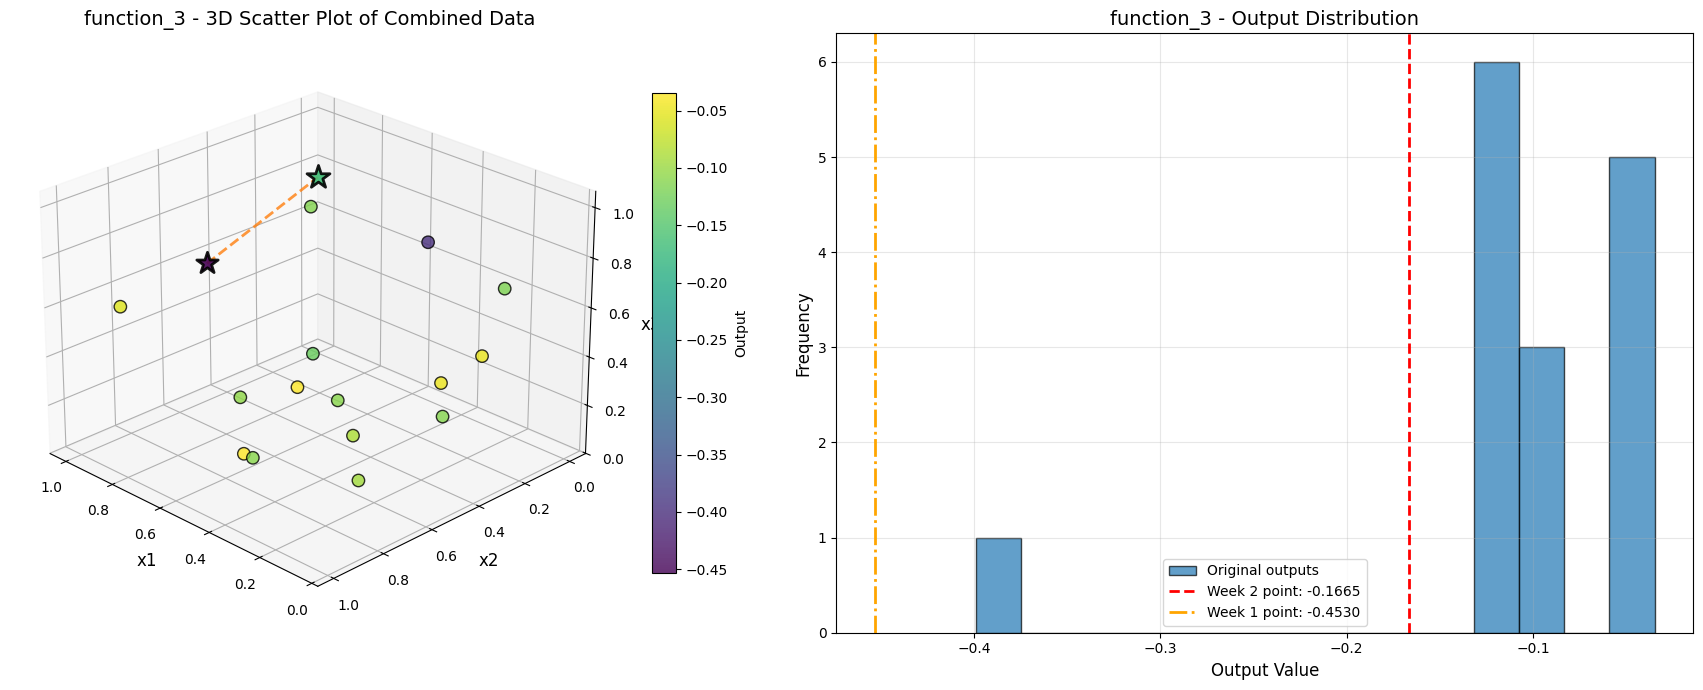


Combined inputs shape: (17, 3)
Combined outputs shape: (17,)


In [10]:
# Function 3 - Visualization using utility function
function_name = 'function_3'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Visualize: show both Week 1 and Week 2 points with a connecting line
plot_3d_scatter_with_distribution(
    original_inputs, original_outputs, 
    week2_input, week2_output, 
    function_name,
    prior_input=week1_input,
    prior_output=week1_output,
    prior_point_label="Week 1 point",
    new_point_label="Week 2 point",
    connect_points=True,
    connect_color="tab:orange"
)

# Print combined data info
combined_inputs = np.vstack([original_inputs, week1_input.reshape(1, -1), week2_input.reshape(1, -1)])
combined_outputs = np.concatenate([original_outputs, np.array([week1_output]), np.array([week2_output])])
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 4 - COMBINED DATA AND VISUALISATION

In [11]:
# Function 4 - Combine original data with week 1 and week 2 data
function_name = 'function_4'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']

# Get week 2 new input and output
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Combine inputs: original + week 1 + week 2
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1)
])

# Combine outputs: original + week 1 + week 2
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output])
])

print("=" * 60)
print(f"FUNCTION 4 - COMBINED DATA (Week 1 + Week 2)")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nWeek 1 input: {week1_input}")
print(f"Week 2 input: {week2_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nWeek 1 output: {week1_output}")
print(f"Week 2 output: {week2_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 4 - COMBINED DATA (Week 1 + Week 2)

Original inputs shape: (30, 4)
Original inputs:
[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 

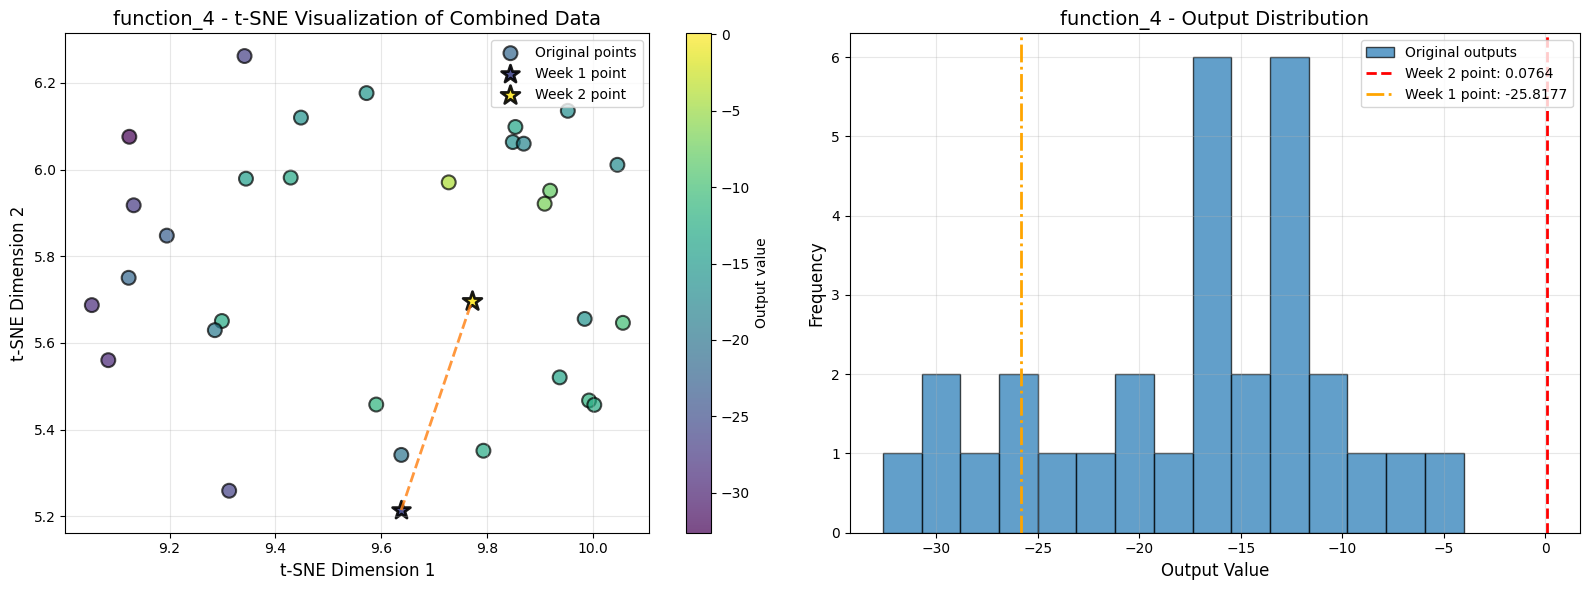


Combined inputs shape: (32, 4)
Combined outputs shape: (32,)


In [12]:
# Function 4 - Visualization using utility function
function_name = 'function_4'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Visualize: show both Week 1 and Week 2 points with a connecting line
plot_tsne_with_distribution(
    original_inputs, original_outputs, 
    week2_input, week2_output, 
    function_name,
    prior_input=week1_input,
    prior_output=week1_output,
    prior_point_label="Week 1 point",
    new_point_label="Week 2 point",
    connect_points=True,
    connect_color="tab:orange"
)

# Print combined data info
combined_inputs = np.vstack([original_inputs, week1_input.reshape(1, -1), week2_input.reshape(1, -1)])
combined_outputs = np.concatenate([original_outputs, np.array([week1_output]), np.array([week2_output])])
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 5 - COMBINED DATA AND VISUALISATION

In [13]:
# Function 5 - Combine original data with week 1 and week 2 data
function_name = 'function_5'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']

# Get week 2 new input and output
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Combine inputs: original + week 1 + week 2
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1)
])

# Combine outputs: original + week 1 + week 2
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output])
])

print("=" * 60)
print(f"FUNCTION 5 - COMBINED DATA (Week 1 + Week 2)")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nWeek 1 input: {week1_input}")
print(f"Week 2 input: {week2_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nWeek 1 output: {week1_output}")
print(f"Week 2 output: {week2_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 5 - COMBINED DATA (Week 1 + Week 2)

Original inputs shape: (20, 4)
Original inputs:
[[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 

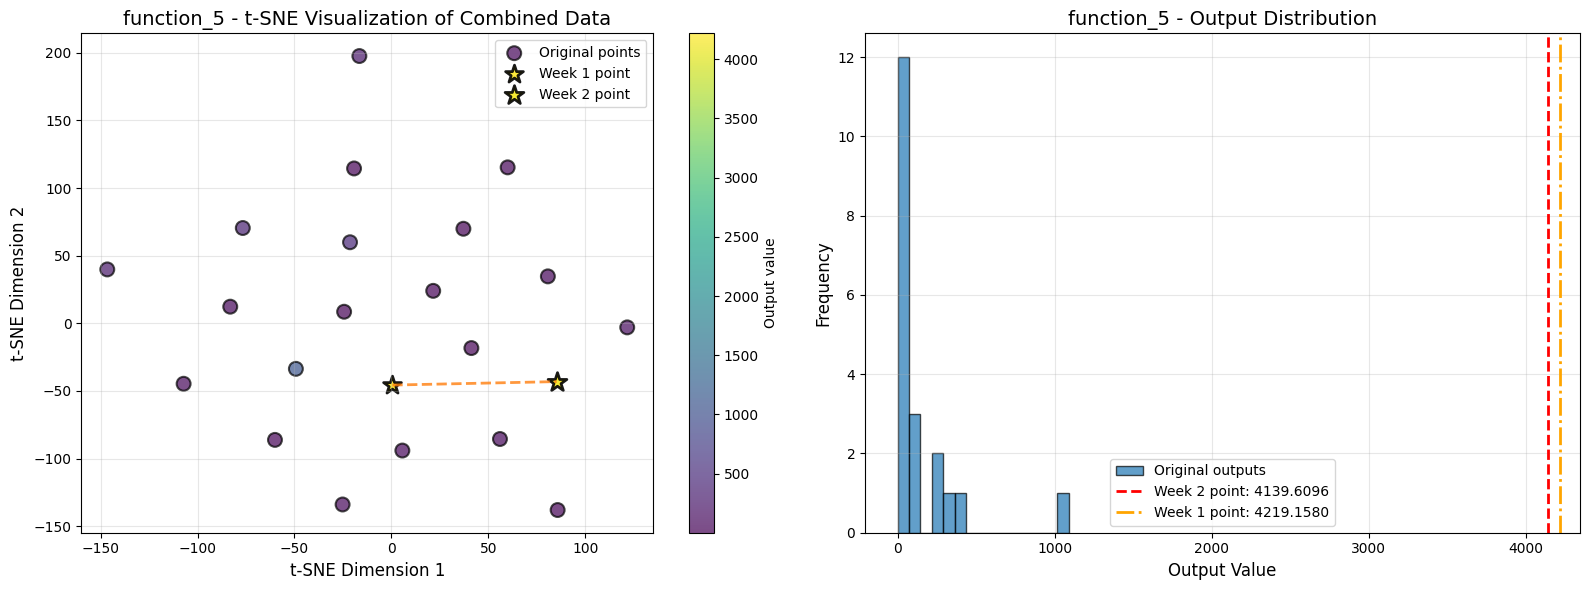


Combined inputs shape: (22, 4)
Combined outputs shape: (22,)


In [14]:
# Function 5 - Visualization using utility function
function_name = 'function_5'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Visualize: show both Week 1 and Week 2 points with a connecting line
plot_tsne_with_distribution(
    original_inputs, original_outputs, 
    week2_input, week2_output, 
    function_name,
    prior_input=week1_input,
    prior_output=week1_output,
    prior_point_label="Week 1 point",
    new_point_label="Week 2 point",
    connect_points=True,
    connect_color="tab:orange"
)

# Print combined data info
combined_inputs = np.vstack([original_inputs, week1_input.reshape(1, -1), week2_input.reshape(1, -1)])
combined_outputs = np.concatenate([original_outputs, np.array([week1_output]), np.array([week2_output])])
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 6 - COMBINED DATA AND VISUALISATION

In [15]:
# Function 6 - Combine original data with week 1 and week 2 data
function_name = 'function_6'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']

# Get week 2 new input and output
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Combine inputs: original + week 1 + week 2
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1)
])

# Combine outputs: original + week 1 + week 2
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output])
])

print("=" * 60)
print(f"FUNCTION 6 - COMBINED DATA (Week 1 + Week 2)")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nWeek 1 input: {week1_input}")
print(f"Week 2 input: {week2_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nWeek 1 output: {week1_output}")
print(f"Week 2 output: {week2_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 6 - COMBINED DATA (Week 1 + Week 2)

Original inputs shape: (20, 5)
Original inputs:
[[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0

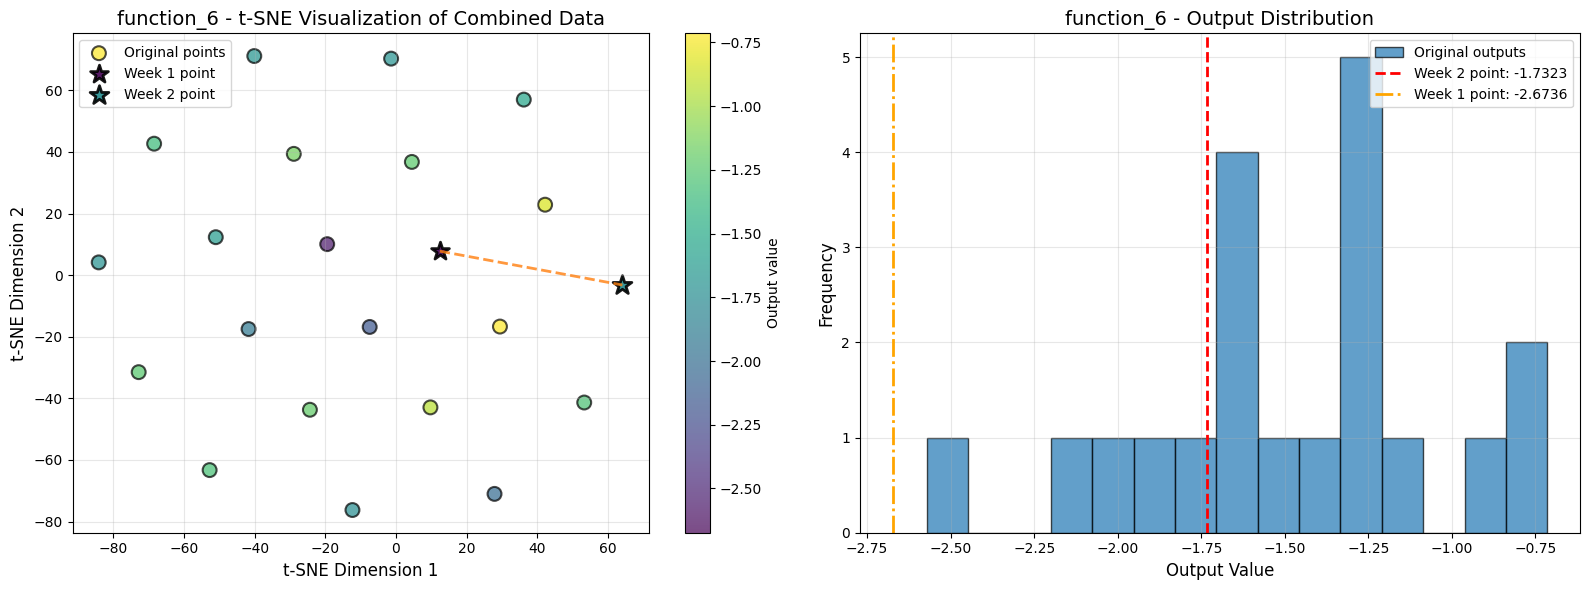


Combined inputs shape: (22, 5)
Combined outputs shape: (22,)


In [16]:
# Function 6 - Visualization using utility function
function_name = 'function_6'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Visualize: show both Week 1 and Week 2 points with a connecting line
plot_tsne_with_distribution(
    original_inputs, original_outputs, 
    week2_input, week2_output, 
    function_name,
    prior_input=week1_input,
    prior_output=week1_output,
    prior_point_label="Week 1 point",
    new_point_label="Week 2 point",
    connect_points=True,
    connect_color="tab:orange"
)

# Print combined data info
combined_inputs = np.vstack([original_inputs, week1_input.reshape(1, -1), week2_input.reshape(1, -1)])
combined_outputs = np.concatenate([original_outputs, np.array([week1_output]), np.array([week2_output])])
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 7 - COMBINED DATA AND VISUALISATION

In [17]:
# Function 7 - Combine original data with week 1 and week 2 data
function_name = 'function_7'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']

# Get week 2 new input and output
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Combine inputs: original + week 1 + week 2
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1)
])

# Combine outputs: original + week 1 + week 2
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output])
])

print("=" * 60)
print(f"FUNCTION 7 - COMBINED DATA (Week 1 + Week 2)")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nWeek 1 input: {week1_input}")
print(f"Week 2 input: {week2_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nWeek 1 output: {week1_output}")
print(f"Week 2 output: {week2_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 7 - COMBINED DATA (Week 1 + Week 2)

Original inputs shape: (30, 6)
Original inputs:
[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245

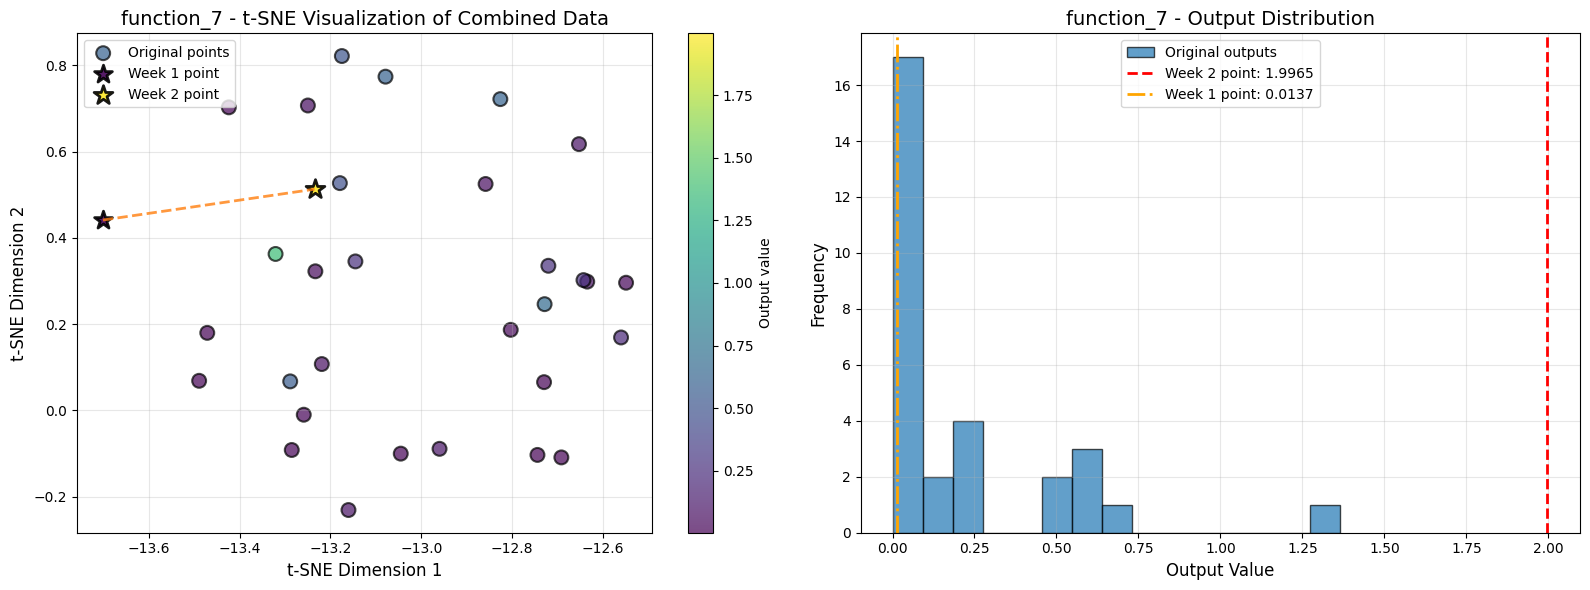


Combined inputs shape: (32, 6)
Combined outputs shape: (32,)


In [18]:
# Function 7 - Visualization using utility function
function_name = 'function_7'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Visualize: show both Week 1 and Week 2 points with a connecting line
plot_tsne_with_distribution(
    original_inputs, original_outputs, 
    week2_input, week2_output, 
    function_name,
    prior_input=week1_input,
    prior_output=week1_output,
    prior_point_label="Week 1 point",
    new_point_label="Week 2 point",
    connect_points=True,
    connect_color="tab:orange"
)

# Print combined data info
combined_inputs = np.vstack([original_inputs, week1_input.reshape(1, -1), week2_input.reshape(1, -1)])
combined_outputs = np.concatenate([original_outputs, np.array([week1_output]), np.array([week2_output])])
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 8 - COMBINED DATA AND VISUALISATION

In [19]:
# Function 8 - Combine original data with week 1 and week 2 data
function_name = 'function_8'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']

# Get week 2 new input and output
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Combine inputs: original + week 1 + week 2
combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1)
])

# Combine outputs: original + week 1 + week 2
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output])
])

print("=" * 60)
print(f"FUNCTION 8 - COMBINED DATA (Week 1 + Week 2)")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nWeek 1 input: {week1_input}")
print(f"Week 2 input: {week2_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nWeek 1 output: {week1_output}")
print(f"Week 2 output: {week2_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 8 - COMBINED DATA (Week 1 + Week 2)

Original inputs shape: (40, 8)
Original inputs:
[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
 

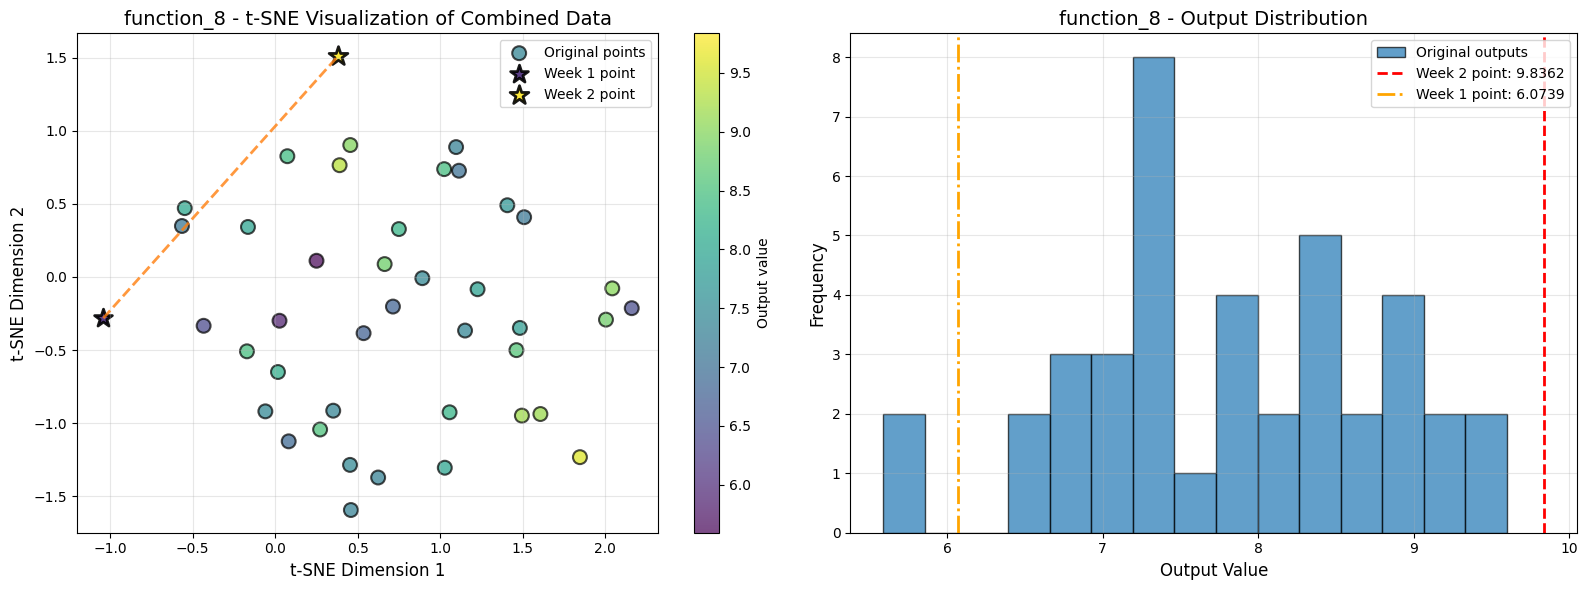


Combined inputs shape: (42, 8)
Combined outputs shape: (42,)


In [20]:
# Function 8 - Visualization using utility function
function_name = 'function_8'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']

# Visualize: show both Week 1 and Week 2 points with a connecting line
plot_tsne_with_distribution(
    original_inputs, original_outputs, 
    week2_input, week2_output, 
    function_name,
    prior_input=week1_input,
    prior_output=week1_output,
    prior_point_label="Week 1 point",
    new_point_label="Week 2 point",
    connect_points=True,
    connect_color="tab:orange"
)

# Print combined data info
combined_inputs = np.vstack([original_inputs, week1_input.reshape(1, -1), week2_input.reshape(1, -1)])
combined_outputs = np.concatenate([original_outputs, np.array([week1_output]), np.array([week2_output])])
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### BAYESIAN OPTIMIZATION - GP + UCB

In [21]:
# Import the Bayesian Optimization module
from scripts.bayesian_optimisation import SimpleBayesianOptimizationStandard as SimpleBayesianOptimization


In [22]:
# Prepare data for Bayesian Optimization
# We'll use the combined data (original + week 1 + week 2) as our starting observations

bo_results = {}

for function_num in range(1, 9):
    function_name = f'function_{function_num}'
    
    # Get combined data
    original_inputs = initial_data[function_name]['inputs']
    original_outputs = initial_data[function_name]['outputs']
    week1_input = week1_data[function_name]['input']
    week1_output = week1_data[function_name]['output']
    week2_input = week2_data[function_name]['input']
    week2_output = week2_data[function_name]['output']
    
    # Combine all observed data
    X_observed = np.vstack([
        original_inputs, 
        week1_input.reshape(1, -1),
        week2_input.reshape(1, -1)
    ])
    y_observed = np.concatenate([
        original_outputs, 
        np.array([week1_output]),
        np.array([week2_output])
    ])
    
    # Define bounds (all functions have inputs in [0, 1])
    n_dims = X_observed.shape[1]
    bounds = [[0.0, 1.0]] * n_dims
    
    # Create BO object
    bo = SimpleBayesianOptimization(bounds=bounds, n_initial=0, random_state=42)
    
    # Fit GP to observed data
    bo.fit(X_observed, y_observed)
    
    # Store results
    bo_results[function_name] = {
        'bo': bo,
        'X_observed': X_observed,
        'y_observed': y_observed,
        'n_dims': n_dims,
        'week1_input': week1_input,
        'week1_output': week1_output,
        'week2_input': week2_input,
        'week2_output': week2_output,
    }
    
    print(f"{function_name}: Fitted GP to {len(X_observed)} observations ({n_dims}D)")


function_1: Fitted GP to 12 observations (2D)
function_2: Fitted GP to 12 observations (2D)
function_3: Fitted GP to 17 observations (3D)
function_4: Fitted GP to 32 observations (4D)
function_5: Fitted GP to 22 observations (4D)
function_6: Fitted GP to 22 observations (5D)


/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is clos

function_7: Fitted GP to 32 observations (6D)
function_8: Fitted GP to 42 observations (8D)


In [23]:
# Suggest next points for all functions using UCB
next_points_bo = {}
ucb_values = {}

print("=" * 60)
print("BAYESIAN OPTIMIZATION - NEXT POINT SUGGESTIONS")
print("=" * 60)

for function_num in range(1, 9):
    function_name = f'function_{function_num}'
    bo = bo_results[function_name]['bo']
    
    # Suggest next point using UCB
    next_point = bo.suggest_next_point(beta=2.0)
    
    # Get UCB value at this point
    ucb_value = bo.acquisition_ucb(next_point.reshape(1, -1), beta=2.0)[0]
    
    next_points_bo[function_name] = next_point
    ucb_values[function_name] = ucb_value
    
    # Format point for display
    formatted_point = '-'.join([f'{x:.6f}' for x in next_point])
    
    print(f"\n{function_name}:")
    print(f"  Suggested point: {formatted_point}")
    print(f"  UCB value: {ucb_value:.6f}")

print("=" * 60)


BAYESIAN OPTIMIZATION - NEXT POINT SUGGESTIONS

function_1:
  Suggested point: 0.000000-0.000000
  UCB value: 0.000463

function_2:
  Suggested point: 0.763745-0.848033
  UCB value: 0.896295

function_3:
  Suggested point: 1.000000-1.000000-0.000000
  UCB value: 0.321519

function_4:
  Suggested point: 0.434166-0.428579-0.217539-0.429707
  UCB value: 0.443944

function_5:
  Suggested point: 0.939030-0.958851-0.959387-0.818091
  UCB value: 4220.766366

function_6:
  Suggested point: 0.230014-0.000000-1.000000-1.000000-0.000000
  UCB value: 0.885722

function_7:
  Suggested point: 0.000000-0.197220-0.363340-0.045543-0.317971-0.937275
  UCB value: 2.337852

function_8:
  Suggested point: 0.025280-0.201174-0.025933-0.196286-1.000000-0.666219-0.190159-0.771074
  UCB value: 10.399461


### SANITY CHECK - Visualize GP Predictions and UCB

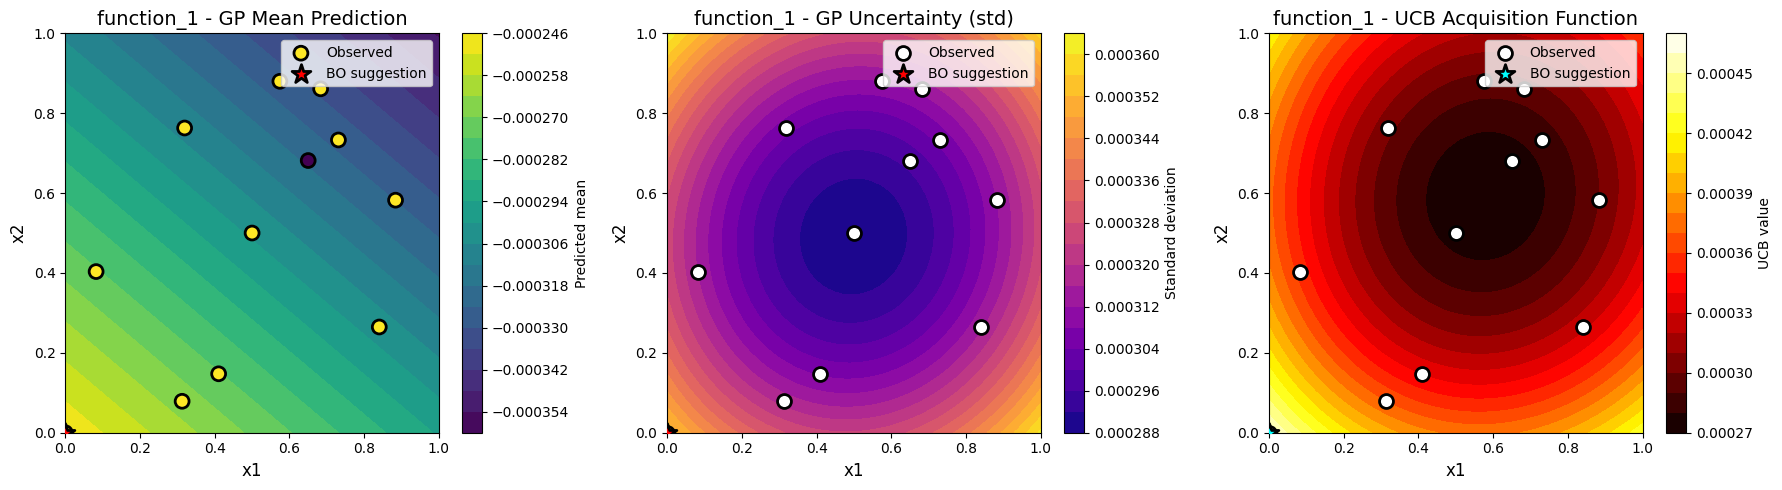


Function 1 BO Summary:
  Observed points: 12
  Best observed value: 0.000000
  Suggested next point: [0.000000, 0.000000]
  UCB value at suggestion: 0.000463


In [24]:
# Sanity check: Visualize GP predictions for Function 1 (2D - easy to visualize)
function_name = 'function_1'
bo = bo_results[function_name]['bo']
X_obs = bo_results[function_name]['X_observed']
y_obs = bo_results[function_name]['y_observed']
next_point = next_points_bo[function_name]

# Use utility function for BO visualization
plot_bo_visualization_2d(bo, X_obs, y_obs, next_point, function_name)

print(f"\nFunction 1 BO Summary:")
print(f"  Observed points: {len(X_obs)}")
print(f"  Best observed value: {y_obs.max():.6f}")
print(f"  Suggested next point: [{next_point[0]:.6f}, {next_point[1]:.6f}]")
print(f"  UCB value at suggestion: {ucb_values[function_name]:.6f}")


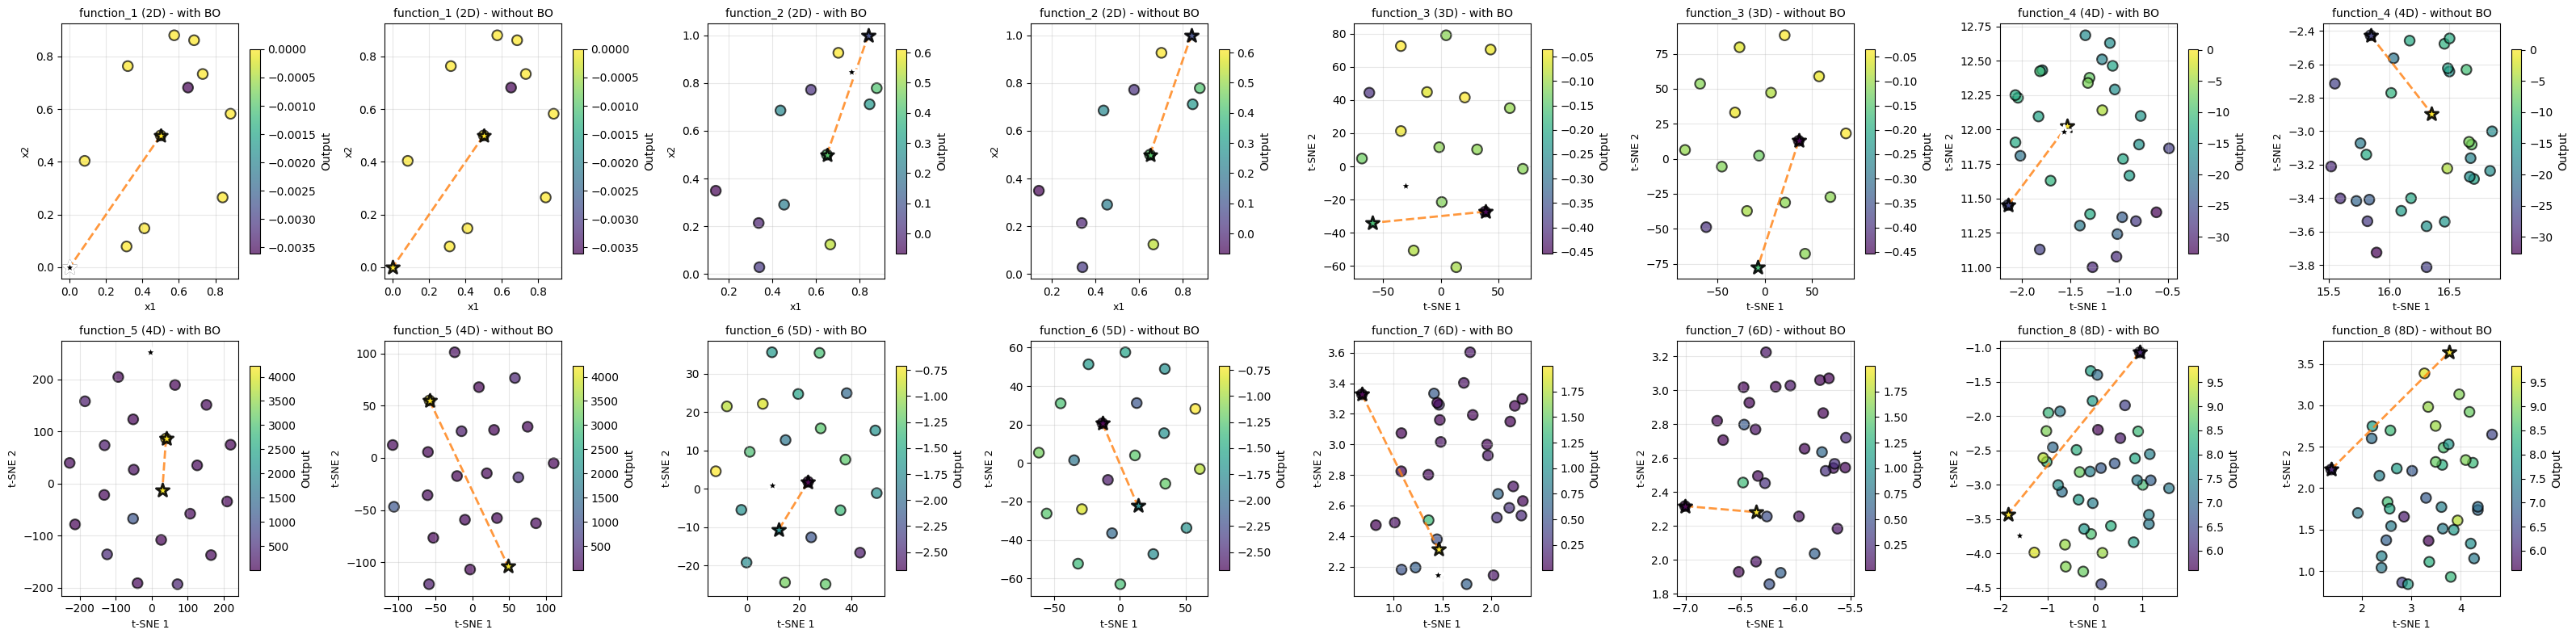


Summary:
  Left plots: Visualization WITH BO point included in t-SNE/scatter
  Right plots: Visualization WITHOUT BO point (matches individual plot style)
  Orange dashed line: Week 1 -> Week 2
  Black stars: BO-suggested next points (only visible in left plots)


In [29]:
# Sanity check: Compare BO suggestions with observed data for all functions
# Left plot shows visualization WITH BO point, right plot shows WITHOUT BO point (matching individual plots)

# Reload the module to ensure we have the latest version
import importlib
import scripts.utils.data_utils as data_utils
importlib.reload(data_utils)
from scripts.utils.data_utils import plot_function_summary_subplot

fig, axes = plt.subplots(2, 8, figsize=(32, 8))
axes = axes.flatten()

for idx, function_num in enumerate(range(1, 9)):
    function_name = f'function_{function_num}'
    
    # Get data
    original_inputs = initial_data[function_name]['inputs']
    original_outputs = initial_data[function_name]['outputs']
    week1_input = bo_results[function_name]['week1_input']
    week1_output = bo_results[function_name]['week1_output']
    week2_input = bo_results[function_name]['week2_input']
    week2_output = bo_results[function_name]['week2_output']
    bo_next_point = next_points_bo[function_name]
    n_dims = bo_results[function_name]['n_dims']
    
    # Treat week 1 as prior, week 2 as latest
    inputs_with_week1 = np.vstack([original_inputs, week1_input.reshape(1, -1)])
    outputs_with_week1 = np.concatenate([original_outputs, np.array([week1_output])])
    
    # Get left and right axes for this function (2 subplots per function)
    ax_left = axes[idx * 2]
    ax_right = axes[idx * 2 + 1]
    
    # Use utility function to plot
    # Left: with BO point, Right: without BO point (matches individual plot style)
    plot_function_summary_subplot(
        ax_left, ax_right,
        inputs_with_week1, outputs_with_week1,
        week2_input, week2_output,
        bo_next_point,
        function_name, n_dims,
        week1_input=week1_input,
        week1_output=week1_output
    )

plt.tight_layout()
plt.show()

print("\nSummary:")
print("  Left plots: Visualization WITH BO point included in t-SNE/scatter")
print("  Right plots: Visualization WITHOUT BO point (matches individual plot style)")
print("  Orange dashed line: Week 1 -> Week 2")
print("  Black stars: BO-suggested next points (only visible in left plots)")


In [30]:
# Print all BO suggestions in format ready for submission

print("=" * 60)
print("BAYESIAN OPTIMIZATION - NEXT POINTS FOR SUBMISSION")
print("=" * 60)
print("\nFormat: x1-x2-x3-... (one point per function)")
print()

for function_num in range(1, 9):
    function_name = f'function_{function_num}'
    next_point = next_points_bo[function_name]
    formatted_point = '-'.join([f'{x:.6f}' for x in next_point])
    print(f"{function_name}: {formatted_point}")

print()
print("=" * 60)


BAYESIAN OPTIMIZATION - NEXT POINTS FOR SUBMISSION

Format: x1-x2-x3-... (one point per function)

function_1: 0.000000-0.000000
function_2: 0.763745-0.848033
function_3: 1.000000-1.000000-0.000000
function_4: 0.434166-0.428579-0.217539-0.429707
function_5: 0.939030-0.958851-0.959387-0.818091
function_6: 0.230014-0.000000-1.000000-1.000000-0.000000
function_7: 0.000000-0.197220-0.363340-0.045543-0.317971-0.937275
function_8: 0.025280-0.201174-0.025933-0.196286-1.000000-0.666219-0.190159-0.771074



####NOTE ON WEEK 1 DATA

The model is struggling with this function and has given me an output the same as last week. 

Because the function is so flat, and everything looks the same, it's tending to extremes. 

I could fix this by adjusting the Bayesien Optimisation. But instead, I really should move to logistic regression.

For now, I'm going to pick a point close to the transition which is 0.6,0.6.. I will code a logistic regression next week! 